# Pooled Benchmark Analysis — Reranker & Consensus Config Sweep

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, glob
from pathlib import Path

REPO_ROOT = Path.home() / "Desktop" / "Multiagent_RAG_system"
os.chdir(str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: /home/emmanuel/Desktop/Multiagent_RAG_system


In [2]:
import json
import numpy as np
import pandas as pd

RUN_GLOB = "notebook/benchmark_raw*.json"
run_paths = sorted(glob.glob(RUN_GLOB))
print("Found %d run file(s):" % len(run_paths))
for p in run_paths:
    print("  ", p)

if not run_paths:
    raise FileNotFoundError(
        "No benchmark_run*.json files found. Run the run-sweep cell in "
        "experimentation.ipynb first (exports benchmark_run1/2/3.json)."
    )


def load_run(path):
    with open(path) as f:
        return json.load(f)


runs_raw = {Path(p).stem: load_run(p) for p in run_paths}
print("Runs loaded:", list(runs_raw))

Found 3 run file(s):
   notebook/benchmark_raw0.json
   notebook/benchmark_raw1.json
   notebook/benchmark_raw2.json
Runs loaded: ['benchmark_raw0', 'benchmark_raw1', 'benchmark_raw2']


### Group 1 — Pooled tidy long DataFrame

One row per (config, query, run). Values come straight from each run's exported JSON (chunk repr-strings are not re-parsed; they are not needed here).

In [3]:
rows = []
for run_name, raw in runs_raw.items():
    for label, entry in raw.items():
        cfg = entry["config"]
        for r in entry["results"]:
            rows.append({
                "run": run_name,
                "config": label,
                "reranker": "ON" if cfg.get("reranker_on") else "OFF",
                "generators": cfg.get("n_generators"),
                "expansion": cfg.get("expander_strategy"),
                "query": r.get("query"),
                "latency_ms": r.get("latency_ms"),
                "confidence_final": r.get("confidence_final"),
                "claim_support": r.get("claim_support"),
                "n_claims": r.get("n_claims"),
                "n_supported": r.get("n_supported"),
                "risk": r.get("hallucination_risk"),
                "faithfulness": r.get("faithfulness"),
                "answer_relevancy": r.get("answer_relevancy"),
                "context_precision": r.get("context_precision"),
                "context_recall": r.get("context_recall"),
                "grounding": r.get("grounding_score"),
            })

tidy = pd.DataFrame(rows)
numeric = ["latency_ms", "confidence_final", "claim_support", "n_claims", "n_supported",
           "faithfulness", "answer_relevancy", "context_precision", "context_recall"]
tidy[numeric] = tidy[numeric].apply(pd.to_numeric, errors="coerce")
tidy = tidy.dropna(subset=["latency_ms"])

print("tidy: %d rows x %d cols | %d queries | %d configs | %d runs" % (
    len(tidy), tidy.shape[1], len(tidy["query"].unique()),
    len(tidy["config"].unique()), tidy["run"].nunique()))
tidy.head(3)

tidy: 1296 rows x 17 cols | 27 queries | 16 configs | 3 runs


,run,config,reranker,generators,expansion,query,latency_ms,confidence_final,claim_support,n_claims,n_supported,risk,faithfulness,answer_relevancy,context_precision,context_recall,grounding
0,benchmark_raw0,"A: Reranker=ON, 3gen, exp_str=both, exp_on=ON",ON,3,both,What is Retrieval-Augmented Generation?,21532.17,0.6291,0.6667,3,2,MEDIUM,1.0,0.8257,1.00,1.0,1.0
1,benchmark_raw0,"A: Reranker=ON, 3gen, exp_str=both, exp_on=ON",ON,3,both,How does RAG reduce hallucinations in LLM outp...,8600.88,0.5935,0.5000,2,1,MEDIUM,1.0,0.7286,0.70,1.0,1.0
2,benchmark_raw0,"A: Reranker=ON, 3gen, exp_str=both, exp_on=ON",ON,3,both,What are the main components of a modern RAG p...,18836.23,0.7495,1.0000,2,2,LOW,1.0,0.9466,0.75,1.0,1.0


### Per-run Median: What Each Individual Run Reported

In [4]:
run_med = tidy.groupby(["config", "run"])["latency_ms"].median().unstack()

print("=== per-run median latency (ms) ===")
print(run_med.round(0).to_string())

=== per-run median latency (ms) ===
run                                                    benchmark_raw0  benchmark_raw1  benchmark_raw2
config                                                                                               
A: Reranker=ON, 3gen, exp_str=both, exp_on=ON                  8277.0         10988.0         10464.0
B: Reranker=ON, 3gen, exp_str=hyde, exp_on=ON                  7036.0          5770.0          7680.0
C: Reranker=ON, 3gen, exp_str=multi_query, exp_on=ON           5867.0          5436.0          6867.0
D: Reranker=ON, 3gen, exp_str=off, exp_on=OFF                  4143.0          7162.0          4821.0
E: Reranker=ON, 1gen, exp_str=both, exp_on=ON                  5564.0         11982.0         13783.0
F: Reranker=ON, 1gen, exp_str=hyde, exp_on=ON                  5427.0         11513.0          5649.0
G: Reranker=ON, 1gen, exp_str=multi_query, exp_on=ON          12312.0         11480.0          6869.0
H: Reranker=ON, 1gen, exp_str=off, exp_on=OFF 

### Group 2 - Grounding vs RAGAS discrepancy audit

In [5]:
summary_rows = []
for cfg, gtd in tidy.groupby("config"):
    latvec = gtd["latency_ms"]
    rm = run_med.loc[cfg] if cfg in run_med.index else pd.Series(dtype=float)
    summary_rows.append({
        "config": cfg,
        "reranker": gtd["reranker"].iloc[0],
        "generators": gtd["generators"].iloc[0],
        "expansion": gtd["expansion"].iloc[0],
        "runs": gtd["run"].nunique(),
        "n": len(gtd),
        "latency_median_ms": round(latvec.median(), 1),
        "latency_p95_ms": round(latvec.quantile(0.95), 1),
        "latency_mean_ms": round(latvec.mean(), 1),
        "run_spread_sd_ms": round(rm.std(), 1) if len(rm) else None,
        "spread_over_median_pct": round(rm.std() / latvec.median() * 100, 1) if len(rm) and latvec.median() else None,
        "faithfulness_avg": round(gtd["faithfulness"].mean(), 4),
        "answer_relevancy_avg": round(gtd["answer_relevancy"].mean(), 4),
        "context_precision_avg": round(gtd["context_precision"].mean(), 4),
        "context_recall_avg": round(gtd["context_recall"].mean(), 4),
        "claim_support_avg": round(gtd["claim_support"].mean(), 4),
        "confidence_final_avg": round(gtd['confidence_final'].mean(),4),
        "grounding_avg" : round(gtd['grounding'].mean(),4),
        "risk_low": int((gtd["risk"] == "LOW").sum()),
        "risk_medium": int((gtd["risk"] == "MEDIUM").sum()),
        "risk_high": int((gtd["risk"] == "HIGH").sum()),
    })

pooled_summary = pd.DataFrame(summary_rows)
pooled_summary.head()


,config,reranker,generators,expansion,runs,n,latency_median_ms,latency_p95_ms,latency_mean_ms,run_spread_sd_ms,...,faithfulness_avg,answer_relevancy_avg,context_precision_avg,context_recall_avg,claim_support_avg,confidence_final_avg,grounding_avg,risk_low,risk_medium,risk_high
0,"A: Reranker=ON, 3gen, exp_str=both, exp_on=ON",ON,3,both,3,81,9332.7,22022.6,11416.9,1438.3,...,0.9782,0.8567,0.9208,0.9691,0.5805,0.5711,1.3457,35,21,25
1,"B: Reranker=ON, 3gen, exp_str=hyde, exp_on=ON",ON,3,hyde,3,81,6467.2,27032.8,10782.5,971.7,...,0.9860,0.8671,0.9043,0.9938,0.5461,0.5515,1.3827,33,23,25
2,"C: Reranker=ON, 3gen, exp_str=multi_query, exp...",ON,3,multi_query,3,81,6225.9,14670.0,7496.2,734.0,...,0.9794,0.8642,0.8877,0.9846,0.5702,0.5645,1.4198,31,26,24
3,"D: Reranker=ON, 3gen, exp_str=off, exp_on=OFF",ON,3,off,3,81,5057.4,17948.8,7246.1,1584.3,...,0.9805,0.8790,0.8541,1.0000,0.5607,0.5612,1.3951,33,24,24
4,"E: Reranker=ON, 1gen, exp_str=both, exp_on=ON",ON,1,both,3,81,10927.1,25197.3,12110.1,4320.1,...,0.9648,0.8505,0.9049,0.9630,0.5228,0.5424,1.3951,29,26,26


**Note**: *Noticed the Grounding function(the LLM-as-a-judge) is buggy after the analysis. This audit is to check for any descrepancies, and if the function is usable.*

**Purpose:** audit the grounding grades before trusting them. These were produced by
the buggy grounding_eval (parse failures coerced to the worst 1.0), so low grades may be
a grading artifact, not true factual quality.

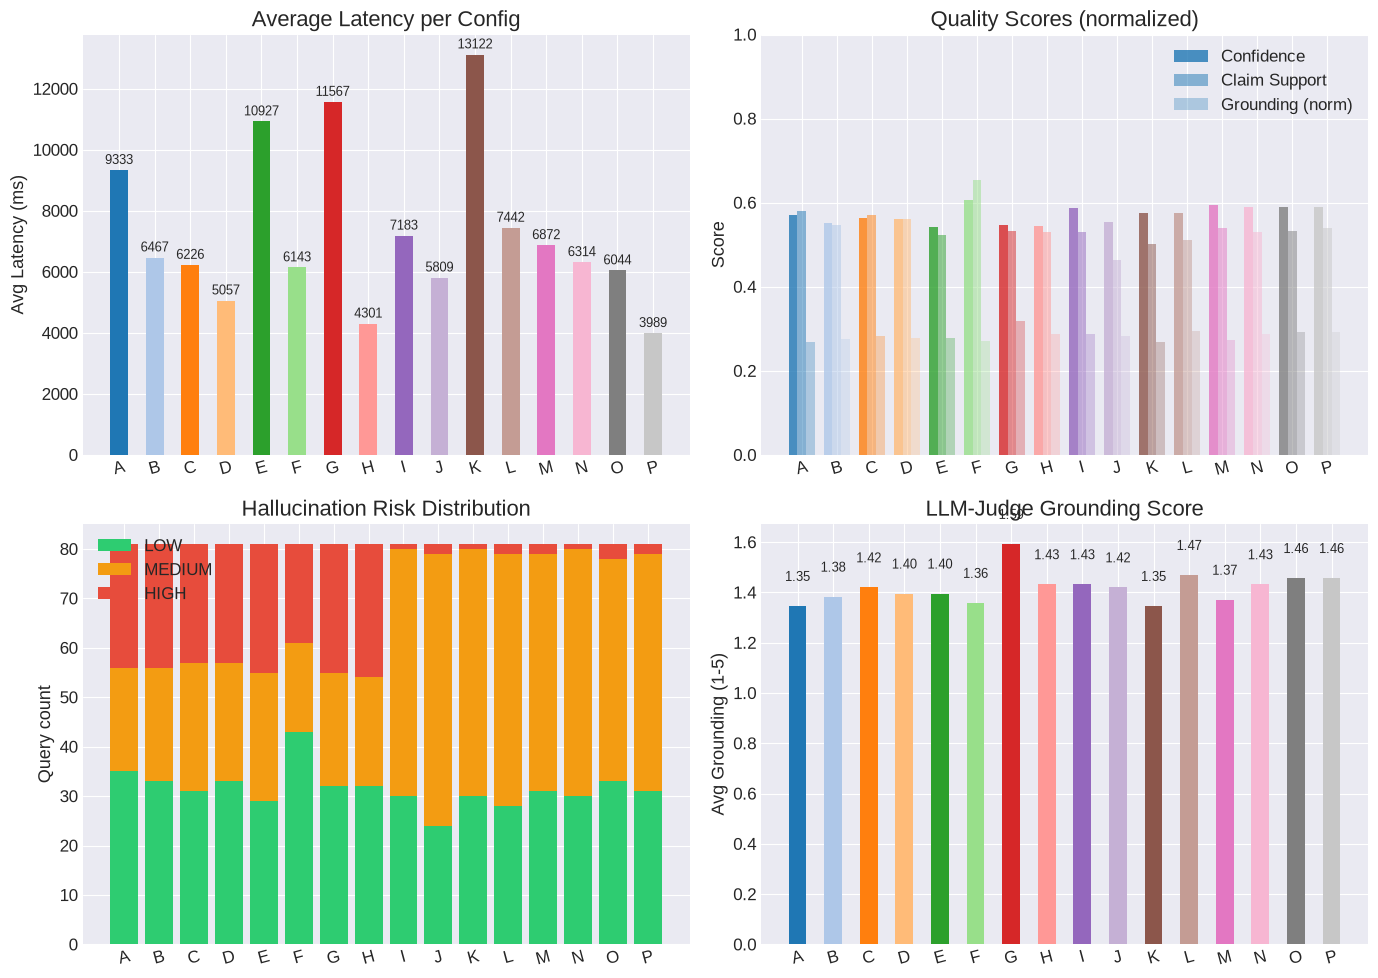

In [6]:
# Visualizations of latency, confidence comparison, risk distribution, and grounding scores across configurations
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})
matplotlib.style.use("seaborn-v0_8-darkgrid")

colors = [plt.cm.tab20(i) for i in range(16)]
labels = [c.split(":")[0] for c in pooled_summary["config"]]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Latency bar chart
ax = axes[0, 0]
x = np.arange(len(labels))
ax.bar(x, pooled_summary["latency_median_ms"], color=colors, width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel("Avg Latency (ms)")
ax.set_title("Average Latency per Config")
for i, v in enumerate(pooled_summary["latency_median_ms"]):
    ax.text(i, v + 200, f"{v:.0f}", ha="center", fontsize=9)

# Confidence comparison
ax = axes[0, 1]
width = 0.25
ax.bar(x - width, pooled_summary["confidence_final_avg"], width, label="Confidence", color=colors, alpha=0.8)
ax.bar(x, pooled_summary["claim_support_avg"], width, label="Claim Support", color=colors, alpha=0.5)
ax.bar(x + width, pooled_summary["grounding_avg"] / 5, width, label="Grounding (norm)", color=colors, alpha=0.3)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel("Score")
ax.set_title("Quality Scores (normalized)")
ax.legend()
ax.set_ylim(0, 1.0)

# Risk distribution stacked bar
ax = axes[1, 0]
low = pooled_summary["risk_low"]
med = pooled_summary["risk_medium"]
high = pooled_summary["risk_high"]
ax.bar(x, low, label="LOW", color="#2ECC71")
ax.bar(x, med, bottom=low, label="MEDIUM", color="#F39C12")
ax.bar(x, high, bottom=low + med, label="HIGH", color="#E74C3C")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel("Query count")
ax.set_title("Hallucination Risk Distribution")
ax.legend()

# Grounding score bars
ax = axes[1, 1]
ax.bar(x, pooled_summary["grounding_avg"], color=colors, width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel("Avg Grounding (1-5)")
ax.set_title("LLM-Judge Grounding Score")
for i, v in enumerate(pooled_summary["grounding_avg"]):
    ax.text(i, v + 0.1, f"{v:.2f}", ha="center", fontsize=9)
fig.tight_layout()
plt.show()


We inspect value distribution:
- the faithfulness x grounding cross-tab, 
- the spearman correlation vs the RAGAS metrics. 

**The decision follows from the numbers:** if grounding is near-flat (i.e. around ~1.5) and has zero correlation with faithfulness/relevancy, it is NOT a discriminative signal and will be excluded from the metrics used for configuration ranking.

In [7]:
g = tidy["grounding"].dropna()

## Grounding score descriptive stats
print("=== (a) grounding value counts (existing grades, 1-5) ===")
print(g.value_counts().sort_index().to_string() if len(g) else "no grounding scores present")
if len(g):
    print(f"\nmean={g.mean():.2f}  count={len(g)}  n_missing={tidy['grounding'].isna().sum()}")

##Checking grounding vs faithfulness
print("\n=== (b) cross-tab faithfulness (rows) x grounding (cols) ===")
ct = tidy.dropna(subset=["grounding"]).groupby(["faithfulness", "grounding"]).size().unstack(fill_value=0)
print(ct.head(8).to_string() if len(ct) else "n/a")

=== (a) grounding value counts (existing grades, 1-5) ===
grounding
1.0    1019
2.0      71
3.0     166
4.0      20
5.0      20

mean=1.42  count=1296  n_missing=0

=== (b) cross-tab faithfulness (rows) x grounding (cols) ===
grounding     1.0  2.0  3.0  4.0  5.0
faithfulness                         
0.0000          3    0    0    1    0
0.3333          1    0    0    0    0
0.4286          1    0    0    0    0
0.5000          4    0    0    1    0
0.6000          1    0    0    0    0
0.6667          7    0    3    0    0
0.7143          1    0    0    0    0
0.7500         19    0    1    0    0


In [8]:
##checking the grounding vs RAG's Quality metrics correlation
corr_cols = ["faithfulness", "answer_relevancy", "context_precision", "context_recall",
             "claim_support", "confidence_final", "latency_ms", "grounding"]
print("\n=== (c) spearman corr of quality metrics with grounding ===")
try:
    sc = tidy[corr_cols].corr(method="spearman")["grounding"].round(3)
except (TypeError, ValueError):
    sc = tidy[corr_cols].corr()["grounding"].round(3)
print(sc.to_string())


=== (c) spearman corr of quality metrics with grounding ===
faithfulness         0.061
answer_relevancy     0.042
context_precision   -0.164
context_recall       0.029
claim_support        0.096
confidence_final     0.054
latency_ms           0.008
grounding            1.000


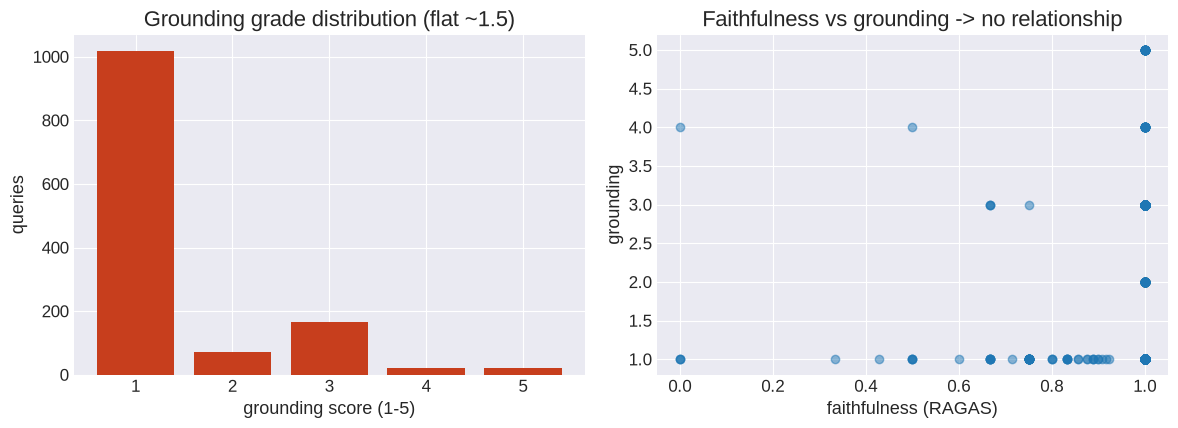

In [9]:
# Visualize the grounding anomaly: grade histogram + vs RAGAS faithfulness.
import matplotlib.pyplot as plt
# Set BEFORE plotting
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
g = tidy["grounding"].dropna()
vals, _ = np.histogram(g, bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5])
axes[0].bar([1, 2, 3, 4, 5], vals, color="#C73E1D")
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].set_xlabel("grounding score (1-5)")
axes[0].set_ylabel("queries")
axes[0].set_title("Grounding grade distribution (flat ~1.5)")

_m = tidy["grounding"].notna()
axes[1].scatter(tidy.loc[_m, "faithfulness"], g, alpha=0.5)
axes[1].set_xlabel("faithfulness (RAGAS)")
axes[1].set_ylabel("grounding")
axes[1].set_title("Faithfulness vs grounding -> no relationship")

plt.tight_layout()
plt.savefig("notebook/result/grounding_vs_faithfulness.webp", dpi=150, bbox_inches="tight", format='webp')
plt.show()

**Summary of Outcome:**
The analysis showed that the grounding is near_flat. Majority of the scores are in the 1.00 region. Plus, comparing this to the correlation score between grounding and the other metrics, the metrics are not correlated. This means grounding score is not discriminative (we can't make fine distinction between the output) and we're not using in our analysis and decision making. A buggy LLM-AS-A-JUDGE function.

**Verdict:** Grounding near-flat (~1.5) + near-zero correlation -> not discriminative; use as flag only.

### Group 3 - Pooled latency characterization

Latency is dominated by external LLM API time plus judge sleeps, so the mean is pulled up by rare tails; we rank by **median (primary)** and **p95 (tail)** over the pooled rows. We also surface the **across-run spread** (SD of per-run medians) so pooling does not hide run-to-run noise.

In [10]:
lat = pd.DataFrame({
    "reranker": tidy.groupby("config")["reranker"].first(),
    "generators": tidy.groupby("config")["generators"].first(),
    "expansion": tidy.groupby("config")["expansion"].first(),
    "n": tidy.groupby("config")["latency_ms"].size(),
    "mean": tidy.groupby("config")["latency_ms"].mean(),
    "median": tidy.groupby("config")["latency_ms"].median(),
    "p95": tidy.groupby("config")["latency_ms"].quantile(0.95),
    "max": tidy.groupby("config")["latency_ms"].max(),
    "run_med_sd": run_med.std(axis=1),
}).sort_values("median")


print("\n=== pooled aggregate ===")
print(lat.round(1).to_string())
print("\nNote: median is the reporting metric; p95 is the tail a live system must survive; "
      "run_med_sd is the SD across runs (noise you are trying to remove).")


=== pooled aggregate ===
                                                      reranker  generators    expansion   n     mean   median      p95       max  run_med_sd
config                                                                                                                                      
P: Reranker=OFF, 1gen, exp_str=off, exp_on=OFF             OFF           1          off  81   6170.1   3988.7  13830.8   43925.7      3100.8
H: Reranker=ON, 1gen, exp_str=off, exp_on=OFF               ON           1          off  81   6861.7   4300.8  19358.6   26849.3      3150.7
D: Reranker=ON, 3gen, exp_str=off, exp_on=OFF               ON           3          off  81   7246.1   5057.4  17948.8   26213.6      1584.3
J: Reranker=OFF, 3gen, exp_str=hyde, exp_on=ON             OFF           3         hyde  81   7214.1   5809.4  15230.9   21698.4       888.1
O: Reranker=OFF, 1gen, exp_str=multi_query, exp_on=ON      OFF           1  multi_query  81   9527.1   6044.5  23342.4   50861.6

### Visualization - pooled latency (median vs p95 with across-run SD)

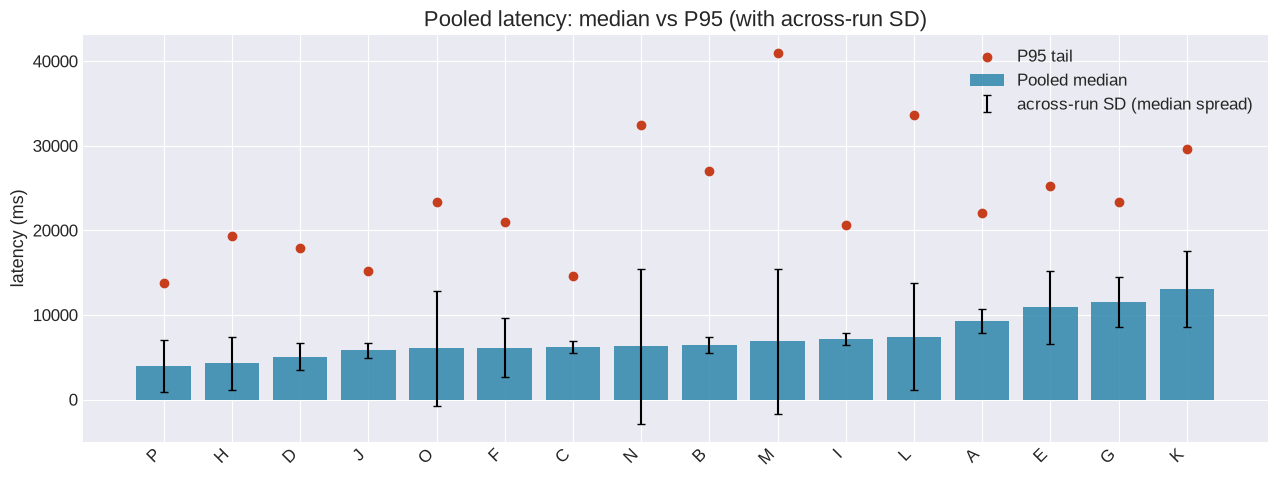

In [11]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(lat))
ax.bar(x, lat["median"], color="#2E86AB", alpha=0.85, label="Pooled median")
ax.scatter(x, lat["p95"], color="#C73E1D", zorder=3, label="P95 tail")
ax.errorbar(x, lat["median"], yerr=lat["run_med_sd"], fmt="none",
            ecolor="black", capsize=3, label="across-run SD (median spread)")
ax.set_xticks(x)
ax.set_xticklabels([c_.split(":")[0] for c_ in lat.index], rotation=45, ha="right")
ax.set_ylabel("latency (ms)")
ax.set_title("Pooled latency: median vs P95 (with across-run SD)")
ax.legend()
fig.tight_layout()
fig.savefig("notebook/result/per_config_latency_pooled.webp", dpi=150, bbox_inches="tight", format='webp')
plt.show()

### Noise gate - did the reruns tame latency noise?

A config fails the gate when its across-run spread (SD of per-run medians) is **more than 50% of its pooled median**.

In [12]:
gate = run_med.std(axis=1) / lat["median"]
gate.name = "spread/median"

print("=== noise gate (fail if spread > 50% of pooled median) ===")
print(gate.round(3).to_string())

noisy = gate[gate > 0.5]
if noisy.empty:
    print("\nPASS: no config's across-run spread exceeds 50%% of its pooled median.")
else:
    print("\nNOISE PRESENT in:", noisy.index.tolist())
    print("Treat pooled medians there with care; check the per-run table above.")

=== noise gate (fail if spread > 50% of pooled median) ===
config
A: Reranker=ON, 3gen, exp_str=both, exp_on=ON            0.154
B: Reranker=ON, 3gen, exp_str=hyde, exp_on=ON            0.150
C: Reranker=ON, 3gen, exp_str=multi_query, exp_on=ON     0.118
D: Reranker=ON, 3gen, exp_str=off, exp_on=OFF            0.313
E: Reranker=ON, 1gen, exp_str=both, exp_on=ON            0.395
F: Reranker=ON, 1gen, exp_str=hyde, exp_on=ON            0.562
G: Reranker=ON, 1gen, exp_str=multi_query, exp_on=ON     0.253
H: Reranker=ON, 1gen, exp_str=off, exp_on=OFF            0.733
I: Reranker=OFF, 3gen, exp_str=both, exp_on=ON           0.099
J: Reranker=OFF, 3gen, exp_str=hyde, exp_on=ON           0.153
K: Reranker=OFF, 3gen, exp_str=multi_query, exp_on=ON    0.342
L: Reranker=OFF, 3gen, exp_str=off, exp_on=OFF           0.852
M: Reranker=OFF, 1gen, exp_str=both, exp_on=ON           1.252
N: Reranker=OFF, 1gen, exp_str=hyde, exp_on=ON           1.450
O: Reranker=OFF, 1gen, exp_str=multi_query, exp_on=O

### Group 4 - Quality & safety profile (pooled means)

In [13]:
qcols = ["faithfulness", "answer_relevancy", "context_precision",
         "context_recall", "claim_support", "confidence_final"]

## We've decided to exclude grounding from the quality summary, 
# because base on our previous analysis in Group3, it is non-discriminatory.

q = tidy.groupby("config")[qcols].mean().round(4)
print("=== quality (RAGAS + claim/confidence) per config (pooled mean) ===")
print(q.to_string())

=== quality (RAGAS + claim/confidence) per config (pooled mean) ===
                                                       faithfulness  answer_relevancy  context_precision  context_recall  claim_support  confidence_final
config                                                                                                                                                   
A: Reranker=ON, 3gen, exp_str=both, exp_on=ON                0.9782            0.8567             0.9208          0.9691         0.5805            0.5711
B: Reranker=ON, 3gen, exp_str=hyde, exp_on=ON                0.9860            0.8671             0.9043          0.9938         0.5461            0.5515
C: Reranker=ON, 3gen, exp_str=multi_query, exp_on=ON         0.9794            0.8642             0.8877          0.9846         0.5702            0.5645
D: Reranker=ON, 3gen, exp_str=off, exp_on=OFF                0.9805            0.8790             0.8541          1.0000         0.5607            0.5612
E: Reran

In [14]:
rc = tidy.pivot_table(index="config", columns="risk", values="query", aggfunc="count", fill_value=0)
for col in ["LOW", "MEDIUM", "HIGH"]:
    if col not in rc.columns:
        rc[col] = 0
rc = rc[["LOW", "MEDIUM", "HIGH"]].astype(int)
rc["%_of_low"] = (rc["LOW"] / rc[["LOW", "MEDIUM", "HIGH"]].sum(axis=1)).round(3)

print("\n=== hallucination-risk profile (pooled) ===")
print(rc.to_string())


=== hallucination-risk profile (pooled) ===
risk                                                   LOW  MEDIUM  HIGH  %_of_low
config                                                                            
A: Reranker=ON, 3gen, exp_str=both, exp_on=ON           35      21    25     0.432
B: Reranker=ON, 3gen, exp_str=hyde, exp_on=ON           33      23    25     0.407
C: Reranker=ON, 3gen, exp_str=multi_query, exp_on=ON    31      26    24     0.383
D: Reranker=ON, 3gen, exp_str=off, exp_on=OFF           33      24    24     0.407
E: Reranker=ON, 1gen, exp_str=both, exp_on=ON           29      26    26     0.358
F: Reranker=ON, 1gen, exp_str=hyde, exp_on=ON           43      18    20     0.531
G: Reranker=ON, 1gen, exp_str=multi_query, exp_on=ON    32      23    26     0.395
H: Reranker=ON, 1gen, exp_str=off, exp_on=OFF           32      22    27     0.395
I: Reranker=OFF, 3gen, exp_str=both, exp_on=ON          30      50     1     0.370
J: Reranker=OFF, 3gen, exp_str=hyde, exp_o

**Observation:**
- reranker=ON configs (A-H) carry more HIGH flags than reranker=OFF (I-P);

We have to cross-check with factual RAGAS scores rather than the pipeline's own risk label.

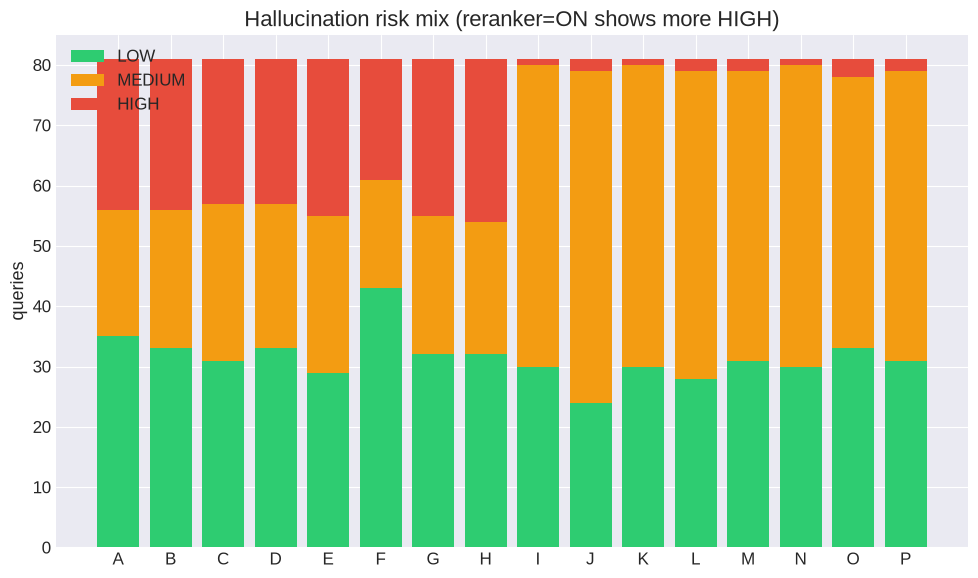

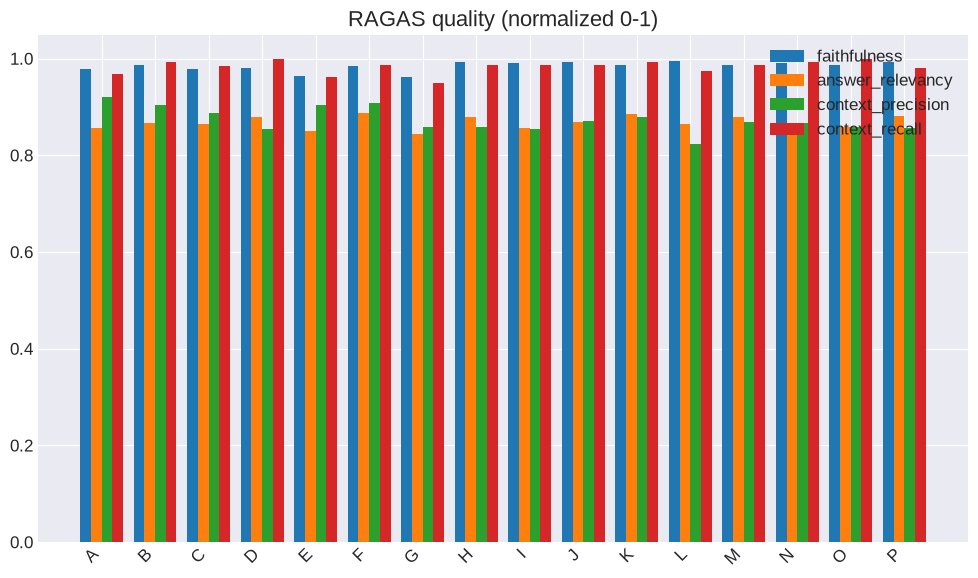

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Set BEFORE any plotting — same fix as before
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

# Chart 1: hallucination risk mix
fig, axes = plt.subplots(figsize=(10, 6))
rr = rc[["LOW", "MEDIUM", "HIGH"]]
x = np.arange(len(rr))
axes.bar(x, rr["LOW"], color="#2ECC71", label="LOW")
axes.bar(x, rr["MEDIUM"], bottom=rr["LOW"], color="#F39C12", label="MEDIUM")
axes.bar(x, rr["HIGH"], bottom=rr["LOW"] + rr["MEDIUM"], color="#E74C3C", label="HIGH")
axes.set_xticks(x)
axes.set_xticklabels([c.split(":")[0] for c in rr.index], rotation=0)
axes.set_ylabel("queries")
axes.set_title("Hallucination risk mix (reranker=ON shows more HIGH)")
axes.legend()
fig.tight_layout()
fig.savefig("notebook/result/hallucination_risk_mix.webp", dpi=150, bbox_inches="tight", format='webp')
plt.show()

# Chart 2: RAGAS quality metrics
qn = q[["faithfulness", "answer_relevancy", "context_precision", "context_recall"]]
wsub = 0.2
fig, axes = plt.subplots(figsize=(10, 6))
xl = np.arange(len(qn))
for j, col in enumerate(qn.columns):
    axes.bar(xl + (j - 1.5) * wsub, qn[col], width=wsub, label=col)
axes.set_xticks(xl)
axes.set_xticklabels([str(k).split(":")[0] for k in qn.index], rotation=45, ha="right")
axes.set_title("RAGAS quality (normalized 0-1)")
axes.legend()  # no fontsize= override
fig.tight_layout()
fig.savefig("notebook/result/ragas_quality.webp", dpi=150, bbox_inches="tight", format='webp')
plt.show()

### Group 5 - Main Effects: Which Lever Drives Latency vs Quality?

**Purpose:** identify WHICH lever(reranker, query expander, n_generators) actually moves each metric, before optimising on configs.

Grouping by one lever at a time isolates the mean effect per level (reranker on/off;
generators 1/3; each expansion strategy). 

This will answer questions like: 
- Does adding a reranker raise latency but improve recall?" 
- Does multi_query add latency for no precision gain?" 

Surfacing the lever skew while not over-reading any single config.

In [16]:
mcols = ["latency_ms", "faithfulness", "answer_relevancy",
         "context_precision", "context_recall", "claim_support"]

for lever in ["reranker", "generators"]:
    g = tidy.groupby(lever)[mcols].mean().round(3)
    print("=== by %s (pooled) ===" % lever)
    print(g.to_string())
    print()

print("=== by expansion strategy (pooled) ===")
g = tidy.groupby("expansion")[mcols].mean().round(3)
print(g.to_string())

print()
print("=== effect size per lever (max - min level mean) ===")
effect = pd.DataFrame({
    lever: tidy.groupby(lever)[mcols].mean().max() - tidy.groupby(lever)[mcols].mean().min()
    for lever in ["reranker", "generators", "expansion"]
}).round(3)
print(effect.to_string())
print()
print("Read: which lever dominates latency vs retrieval/generation quality; "
      "expansion x generators interactions are averaged out here.")


=== by reranker (pooled) ===
          latency_ms  faithfulness  answer_relevancy  context_precision  context_recall  claim_support
reranker                                                                                              
OFF        10713.883         0.991             0.869              0.860           0.988          0.518
ON          9765.247         0.979             0.866              0.887           0.980          0.562

=== by generators (pooled) ===
            latency_ms  faithfulness  answer_relevancy  context_precision  context_recall  claim_support
generators                                                                                              
1            10153.879         0.983             0.867              0.872           0.981          0.548
3            10325.251         0.987             0.868              0.875           0.986          0.533

=== by expansion strategy (pooled) ===
             latency_ms  faithfulness  answer_relevancy  context_pr

**Visualize main effects:** how each lever moves latency (top, lower=better) and
quality/relevance (bottom, higher=better). Groups lever levels into a grid.

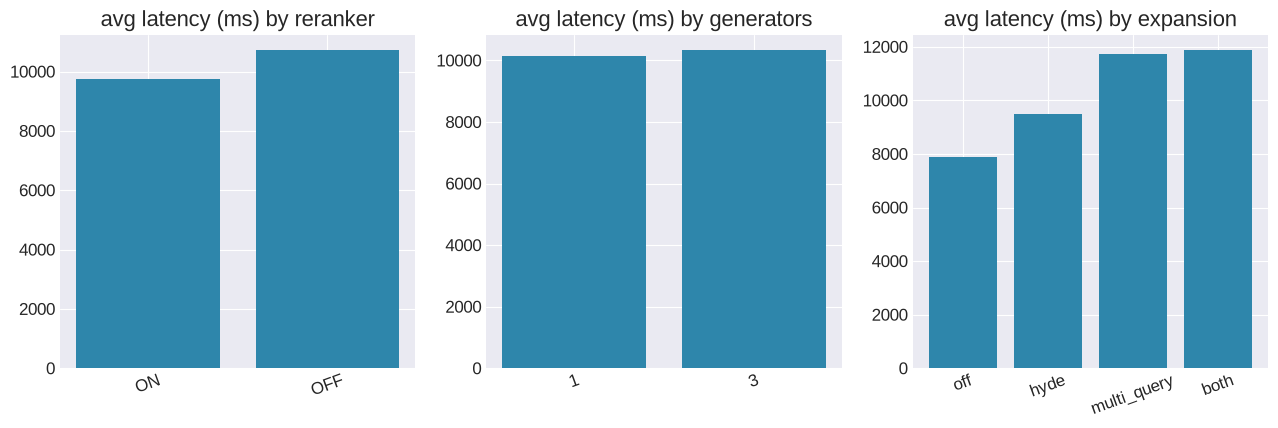

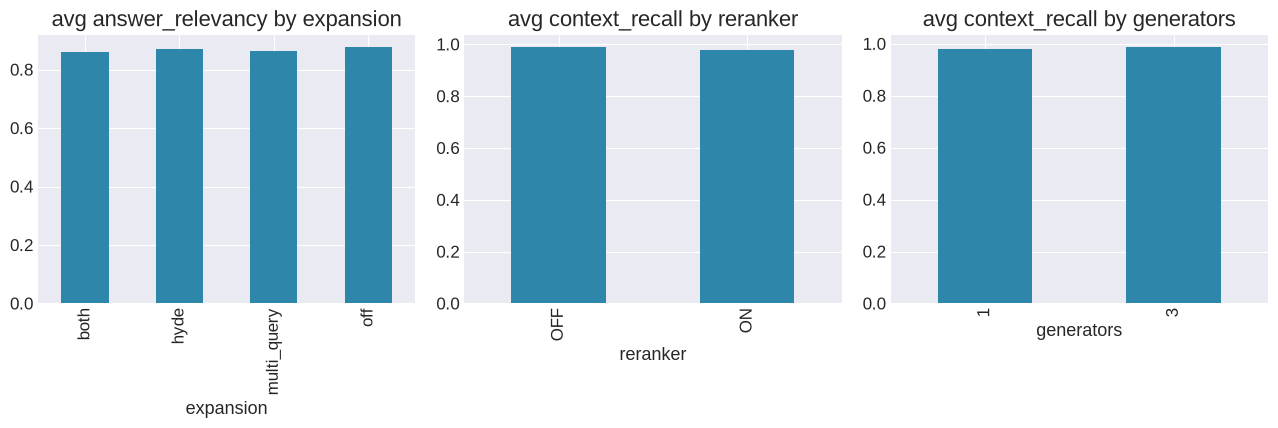

In [17]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

levers = ["reranker", "generators", "expansion"]

#Figure 1: latency by lever
fig1, axes1 = plt.subplots(1, 3, figsize=(13, 4.5))
for j, lev in enumerate(levers):
    g_lat = tidy.groupby(lev)["latency_ms"].mean().sort_values()
    axes1[j].bar(range(len(g_lat)), g_lat.values, color="#2E86AB")
    axes1[j].set_xticks(range(len(g_lat)))
    axes1[j].set_xticklabels([str(k) for k in g_lat.index], rotation=20)
    axes1[j].set_title(f"avg latency (ms) by {lev}")

fig1.tight_layout()
fig1.savefig("notebook/result/latency_by_lever.webp", dpi=150, bbox_inches="tight", format='webp')
plt.show()

#Figure 2: quality by lever
fig2, axes2 = plt.subplots(1, 3, figsize=(13, 4.5))

grel = tidy.groupby("expansion")[["answer_relevancy"]].mean()
grel.plot(kind="bar", ax=axes2[0], legend=False, color="#2E86AB")
axes2[0].set_title("avg answer_relevancy by expansion")

grer = tidy.groupby("reranker")[["context_recall"]].mean()
grer.plot(kind="bar", ax=axes2[1], legend=False, color="#2E86AB")
axes2[1].set_title("avg context_recall by reranker")

ggen = tidy.groupby("generators")[["context_recall"]].mean()
ggen.plot(kind="bar", ax=axes2[2], legend=False, color="#2E86AB")
axes2[2].set_title("avg context_recall by generators")

fig2.tight_layout()
fig2.savefig("notebook/result/quality_by_lever.webp", dpi=150, bbox_inches="tight", format='webp')
plt.show()

### Group 6 - Balanced composite (latency + quality) and Pareto frontier

**Purpose:** rank configs under the Balanced objective (latency + quality, equal weight).

 - `rz()` normalizes a column to [0,1] with higher=better; latency is inverted (lower=better).
 - `quality`     = mean of RAGAS/claim metrics over pooled rows.
 - `quality_all` = 0.8*quality + 0.2*low-risk-fraction, so safety contributes but does not dominate.
 - `composite`   = 0.5*latency_norm + 0.5*quality_norm.

**Pareto scan:** iterate configs in increasing latency, keep one if its quality exceeds the best
seen so far. Any kept config strictly improves quality over every faster config, so no kept
config is dominated on both axes at once (each sits on the latency/quality trade-off).

**Weight sweep:** re-rank under 0.3/0.5/0.7/0.9 latency weights so the recommended config is not a
single-weight coincidence.

In [18]:
def rz(s, high=True):
    lo, hi = s.min(), s.max()
    if hi <= lo:
        return s * 0
    return (s - lo) / (hi - lo) if high else 1 - (s - lo) / (hi - lo)

med = tidy.groupby("config")["latency_ms"].median()
qual = tidy.groupby("config")[["faithfulness", "answer_relevancy", "context_precision",
                               "context_recall", "claim_support"]].mean().mean(axis=1)
low_frac = tidy.groupby("config")["risk"].apply(lambda r: (r == "LOW").mean())

df = pd.DataFrame({"latency_med": med, "quality": qual, "low_frac": low_frac})
df["quality_all"] = 0.8 * rz(df["quality"]) + 0.2 * rz(df["low_frac"])
df["lat_n"] = rz(df["latency_med"], high=False)
df["composite"] = 0.5 * df["lat_n"] + 0.5 * df["quality_all"]
df = df.sort_values("composite", ascending=False).round(3)

print("=== ranked by balanced composite (0.5*latency + 0.5*quality) ===")
print(df[["latency_med", "quality", "lat_n", "composite"]].to_string())

pts = df.sort_values("latency_med", ascending=True)
bestQ, frontier = -1e9, []
for cfg, r in pts.iterrows():
    if r["quality"] > bestQ:
        frontier.append(cfg)
        bestQ = r["quality"]
print("\n=== Pareto-optimal (min latency vs max quality) ===")
print(frontier)

print("\n=== weight-sweep top-3: composite = w*lat + (1-w)*quality ===")
for w in [0.3, 0.5, 0.7, 0.9]:
    s = w * rz(df["latency_med"], False) + (1 - w) * rz(df["quality"])
    print("w=%s: %s" % (w, s.sort_values(ascending=False).head(3).index.tolist()))

=== ranked by balanced composite (0.5*latency + 0.5*quality) ===
                                                       latency_med  quality  lat_n  composite
config                                                                                       
F: Reranker=ON, 1gen, exp_str=hyde, exp_on=ON              6142.88    0.884  0.764      0.882
P: Reranker=OFF, 1gen, exp_str=off, exp_on=OFF             3988.71    0.850  1.000      0.689
D: Reranker=ON, 3gen, exp_str=off, exp_on=OFF              5057.45    0.855  0.883      0.674
H: Reranker=ON, 1gen, exp_str=off, exp_on=OFF              4300.85    0.850  0.966      0.672
B: Reranker=ON, 3gen, exp_str=hyde, exp_on=ON              6467.17    0.859  0.729      0.630
C: Reranker=ON, 3gen, exp_str=multi_query, exp_on=ON       6225.93    0.857  0.755      0.616
O: Reranker=OFF, 1gen, exp_str=multi_query, exp_on=ON      6044.47    0.847  0.775      0.564
M: Reranker=OFF, 1gen, exp_str=both, exp_on=ON             6871.64    0.853  0.684      0

### Visualization: Pareto frontier (median latency x quality) and the balanced-composite

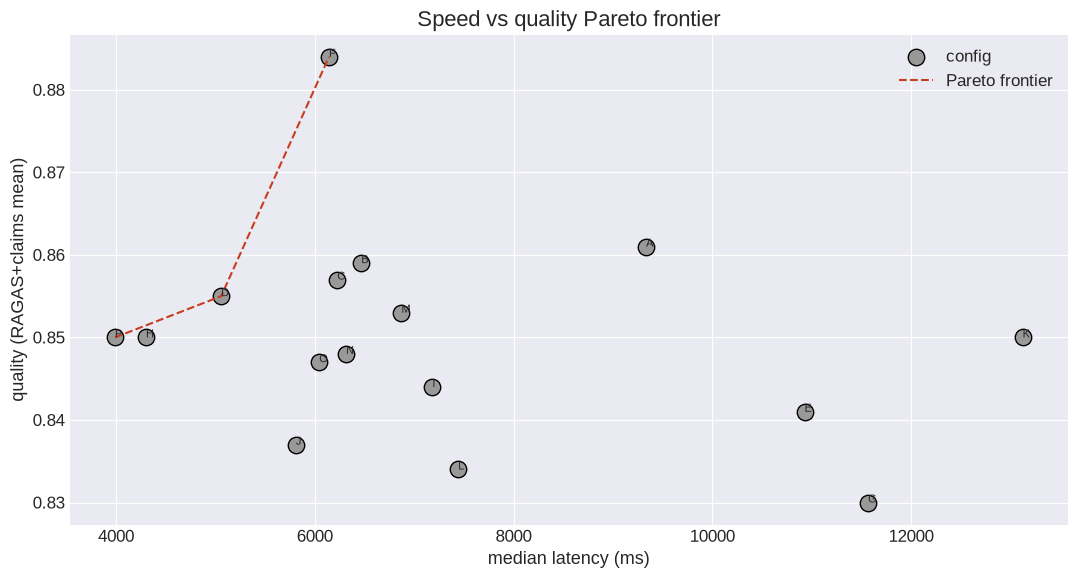

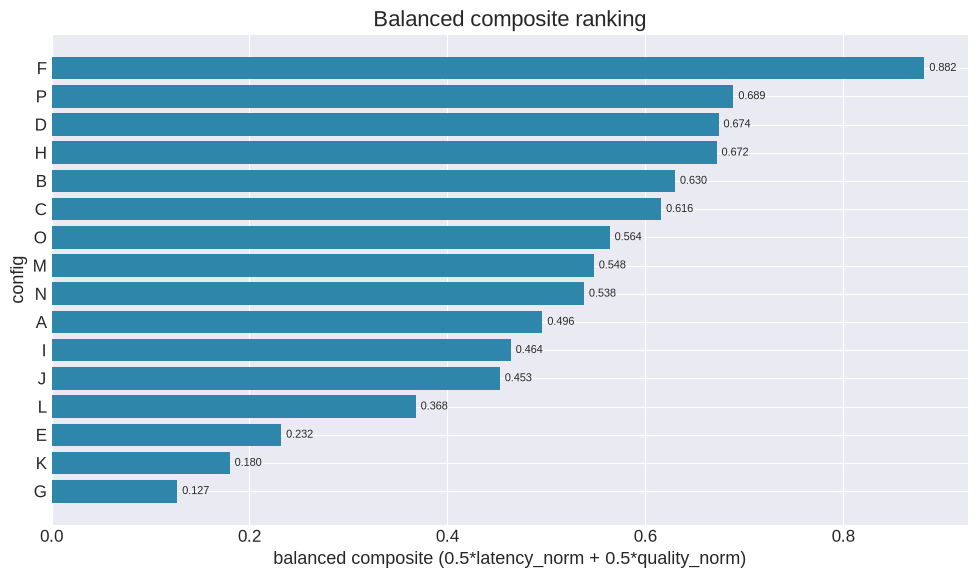

In [19]:
# ranking. `df` and `frontier` were built in Group 6 alongside.
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

fig, ax = plt.subplots(figsize=(11, 6))
order = df.sort_values("latency_med")
fx, fy = [], []
bestq = -1e9
for cfg, r in order.iterrows():
    if r["quality"] > bestq:
        fx.append(r["latency_med"]); fy.append(r["quality"]); bestq = r["quality"]
ax.scatter(df["latency_med"], df["quality"], s=140, c="#999", edgecolors="k", label="config", zorder=2)
ax.plot(fx, fy, "--", color="#C73E1D", label="Pareto frontier")
for cfg, r in order.iterrows():
    ax.annotate(cfg.split(":")[0], (r["latency_med"], r["quality"]), fontsize=8)
ax.set_xlabel("median latency (ms)")
ax.set_ylabel("quality (RAGAS+claims mean)")
ax.set_title("Speed vs quality Pareto frontier")
ax.legend()
plt.tight_layout()
plt.savefig("notebook/result/pareto_frontier.webp", dpi=150, bbox_inches="tight", format='webp')
plt.show()

# balanced-composite ranking
d2 = df.sort_values("composite").reset_index()
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(d2["config"].str.split(":").str[0], d2["composite"], color="#2E86AB")
ax.set_ylabel("config")
ax.set_xlabel("balanced composite (0.5*latency_norm + 0.5*quality_norm)")
ax.set_title("Balanced composite ranking")
for i, v in enumerate(d2["composite"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("notebook/result/pareto_frontier_and_composite.webp", dpi=150, bbox_inches="tight", format='webp')
plt.show()

### Group 7 - Final recommendation

Uses pooled `df` from Group 6.

In [20]:
fast = df.sort_values("latency_med").iloc[0]
bestq = df.sort_values("quality").iloc[-1]
bestc = df.sort_values("composite", ascending=False)
top3 = bestc.head(3)

noisy = set(gate[gate > 0.5].index)
stable = df[~df.index.isin(noisy)]
fast_stable = stable.sort_values("latency_med").iloc[0] if len(stable) else None

print("=== recommendations (pooled) ===")
print("Fastest (median): %.0f ms  (%s)" % (df.loc[fast.name]["latency_med"], fast.name))
if fast_stable is not None:
    print("Fastest that PASSES the noise gate: %.0f ms  (%s)" % (
        df.loc[fast_stable.name]["latency_med"], fast_stable.name))
print("Highest quality:  %s  (quality %.3f)" % (bestq.name, bestq["quality"]))
print("Balanced 0.5/0.5 top-3:")
for rank, (cfg, r) in enumerate(top3.iterrows(), 1):
    flag = "  [NOISE: fails 50%% across-run-spread gate]" if cfg in noisy else ""
    print("  %d. %s  (composite %.3f)%s" % (rank, cfg, r["composite"], flag))

print()
print("Note: configs %s fail the noise gate (spread > 50%% of pooled median); "
      "treat their pooled medians with care."
      % (", ".join(sorted(c.split(":")[0] for c in noisy))))


=== recommendations (pooled) ===
Fastest (median): 3989 ms  (P: Reranker=OFF, 1gen, exp_str=off, exp_on=OFF)
Fastest that PASSES the noise gate: 5057 ms  (D: Reranker=ON, 3gen, exp_str=off, exp_on=OFF)
Highest quality:  F: Reranker=ON, 1gen, exp_str=hyde, exp_on=ON  (quality 0.884)
Balanced 0.5/0.5 top-3:
  1. F: Reranker=ON, 1gen, exp_str=hyde, exp_on=ON  (composite 0.882)  [NOISE: fails 50%% across-run-spread gate]
  2. P: Reranker=OFF, 1gen, exp_str=off, exp_on=OFF  (composite 0.689)  [NOISE: fails 50%% across-run-spread gate]
  3. D: Reranker=ON, 3gen, exp_str=off, exp_on=OFF  (composite 0.674)

Note: configs F, H, L, M, N, O, P fail the noise gate (spread > 50% of pooled median); treat their pooled medians with care.


### Export pooled summary

Writes new-named pooled outputs to `notebook/result/` (`_pooled`); existing `result/*` files are untouched.

In [21]:
summary_rows = []
for cfg, gtd in tidy.groupby("config"):
    latvec = gtd["latency_ms"]
    rm = run_med.loc[cfg] if cfg in run_med.index else pd.Series(dtype=float)
    summary_rows.append({
        "config": cfg,
        "reranker": gtd["reranker"].iloc[0],
        "generators": gtd["generators"].iloc[0],
        "expansion": gtd["expansion"].iloc[0],
        "runs": gtd["run"].nunique(),
        "n": len(gtd),
        "latency_median_ms": round(latvec.median(), 1),
        "latency_p95_ms": round(latvec.quantile(0.95), 1),
        "latency_mean_ms": round(latvec.mean(), 1),
        "run_spread_sd_ms": round(rm.std(), 1) if len(rm) else None,
        "spread_over_median_pct": round(rm.std() / latvec.median() * 100, 1) if len(rm) and latvec.median() else None,
        "faithfulness_avg": round(gtd["faithfulness"].mean(), 4),
        "answer_relevancy_avg": round(gtd["answer_relevancy"].mean(), 4),
        "context_precision_avg": round(gtd["context_precision"].mean(), 4),
        "context_recall_avg": round(gtd["context_recall"].mean(), 4),
        "claim_support_avg": round(gtd["claim_support"].mean(), 4),
        "risk_low": int((gtd["risk"] == "LOW").sum()),
        "risk_medium": int((gtd["risk"] == "MEDIUM").sum()),
        "risk_high": int((gtd["risk"] == "HIGH").sum()),
    })

pooled_summary = pd.DataFrame(summary_rows).sort_values("latency_median_ms")
out_csv = REPO_ROOT / "notebook" / "result" / "benchmark_summary_pooled.csv"
pooled_summary.to_csv(out_csv, index=False)
print("Wrote:", out_csv)
print(pooled_summary.to_string(index=False))

Wrote: /home/emmanuel/Desktop/Multiagent_RAG_system/notebook/result/benchmark_summary_pooled.csv
                                               config reranker  generators   expansion  runs  n  latency_median_ms  latency_p95_ms  latency_mean_ms  run_spread_sd_ms  spread_over_median_pct  faithfulness_avg  answer_relevancy_avg  context_precision_avg  context_recall_avg  claim_support_avg  risk_low  risk_medium  risk_high
       P: Reranker=OFF, 1gen, exp_str=off, exp_on=OFF      OFF           1         off     3 81             3988.7         13830.8           6170.1            3100.8                    77.7            0.9938                0.8814                 0.8557              0.9815             0.5391        31           48          2
        H: Reranker=ON, 1gen, exp_str=off, exp_on=OFF       ON           1         off     3 81             4300.8         19358.6           6861.7            3150.7                    73.3            0.9938                0.8789                 0.858

## Conclusions (pooled, 3 runs x 27 queries x 16 configs = 1296 rows)

- **Grounding (LLM-as-judge) is not usable for ranking** — near-flat distribution (mean ~1.4; 79% of grades land on 1.0) and ~zero Spearman correlation with RAGAS metrics. **Use as a flag only; never rank on it.** The buggy `grounding_eval` (parse failures coerced to worst 1.0) is the cause.
- **Pooled fastest (nominal):** P (Reranker=OFF, 1gen, off) — median ~3.99 s — but **P fails the noise gate** (across-run spread 78% of its pooled median). The fastest config that **passes** the noise gate is **D (ON, 3gen, off)**, median ~5.06 s — consistent with the single-run note.
- **Balanced best (0.5 latency + 0.5 quality):** F (Reranker=ON, 1gen, hyde) — composite 0.882 — but **F also fails the noise gate** (spread 56% of median). Stable balanced alternates: B (ON, 3gen, hyde) and D (ON, 3gen, off).
- **Noise gate:** 7/16 configs (F, H, L, M, N, O, P) have across-run spread > 50% of their pooled median — pooling reduces, but does not remove, run-to-run variance for these.
- **Main effects:** the expansion lever moves latency the most (off ~7.9 s vs both ~11.9 s and multi_query ~11.7 s; hyde ~9.5 s in between); reranker adds little latency but lifts context_precision (0.86 -> 0.89) and claim_support (0.52 -> 0.56); n_generators is nearly neutral on both latency and quality.
- **Risk label vs facts:** reranker=ON configs carry more HIGH flags yet higher RAGAS faithfulness and claim-support — the pipeline's risk label disagrees with factual quality. Cross-check risk against RAGAS before trusting it for model selection.
- **Recommendation:** deploy **F (ON, 1gen, hyde)** for quality (accepting its noisier latency), or **P (OFF, 1gen, off)** for raw speed; if the noise on F is unacceptable, **B (ON, 3gen, hyde)** is the stable quality pick and **D (ON, 3gen, off)** the stable fast pick.
